In [1]:
# EDA: Exploratory Data Analysis

In [31]:
# Import libraries and packages

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from scipy import stats

In [3]:
# Load the cleansed dataset from previous notebook and call it dfc:

dfc = pd.read_csv('/content/cleansed_data.csv')

In [4]:
dfc.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# Check data types since importing an Excel file may breake previous data types:

dfc.dtypes

,0
InvoiceNo,int64
StockCode,object
Description,object
Quantity,float64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [6]:
# InvoiceDate needs to be converted to datetime again:

dfc['InvoiceDate'] = pd.to_datetime(dfc['InvoiceDate'])
dfc.dtypes

,0
InvoiceNo,int64
StockCode,object
Description,object
Quantity,float64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [7]:
# I am going to delete Country column since all transactions happened in United Kingdom.

dfc = dfc.drop('Country', axis=1)

In [8]:
dfc.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0


In [9]:
# Now, I am going to draw some plots to explore the data.

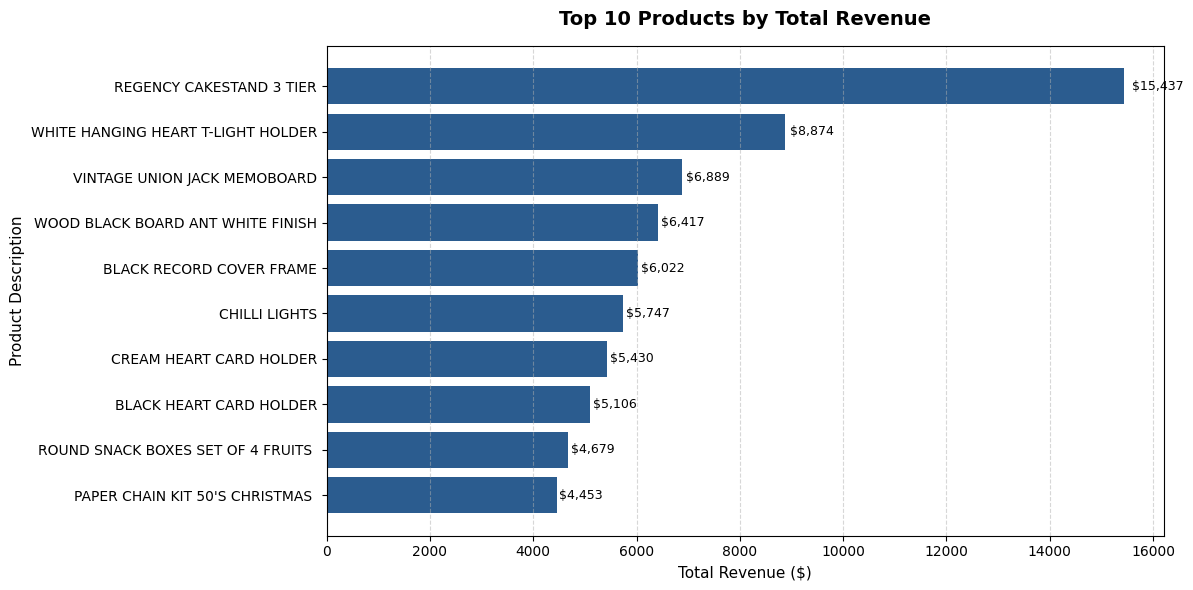

In [10]:
# 1. Create the Revenue column
dfc['Revenue'] = dfc['Quantity'] * dfc['UnitPrice']

# 2. Filter out returns/cancellations (negative values) and missing descriptions
dfc_valid = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)].dropna(
    subset=['Description']
)

# 3. Calculate total revenue per product and take top 10
top10_revenue = (
    dfc_valid.groupby('Description')['Revenue']
    .sum()
    .nlargest(10)
    .sort_values(ascending=True)  # Sort ascending so largest bar is at the top
)

# 4. Create the Matplotlib plot
plt.figure(figsize=(12, 6))

# Plot horizontal bar chart
bars = plt.barh(top10_revenue.index, top10_revenue.values, color='#2b5c8f')

# Add data labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f'${width:,.0f}',
        va='center',
        ha='left',
        fontsize=9,
    )

# Formatting
plt.title('Top 10 Products by Total Revenue', fontsize=14, pad=15, weight='bold')
plt.xlabel('Total Revenue ($)', fontsize=11)
plt.ylabel('Product Description', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Adjust layout to prevent clipping long product names
plt.tight_layout()
plt.show()

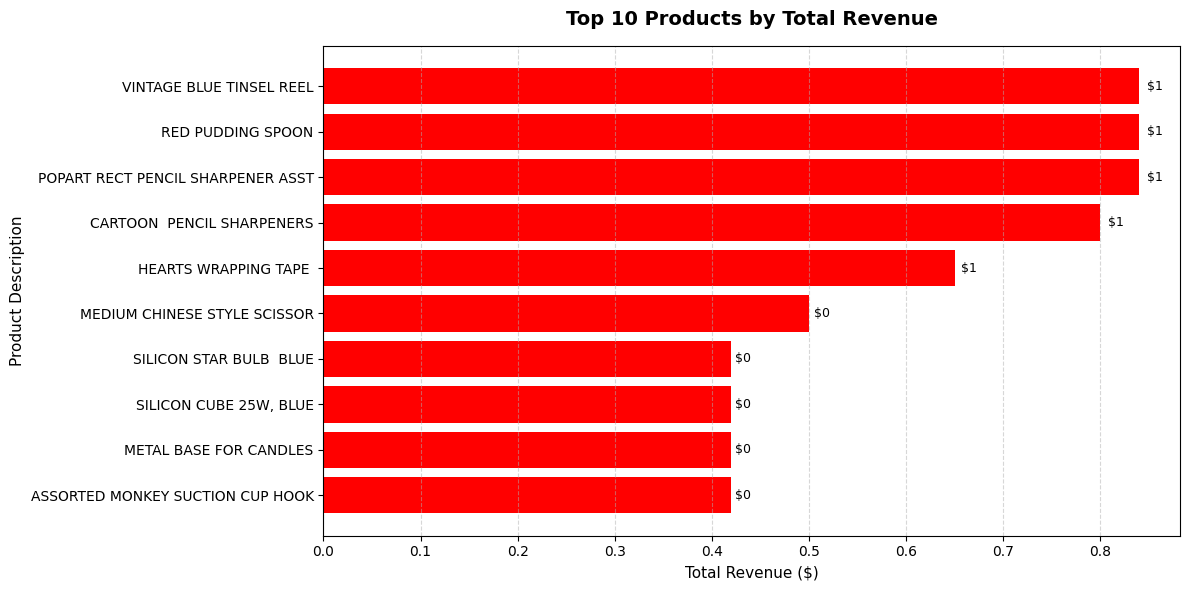

In [11]:
# Now let's see revenue for lowest 10 products:

# 1. Create the Revenue column
dfc['Revenue'] = dfc['Quantity'] * dfc['UnitPrice']

# 2. Filter out returns/cancellations (negative values) and missing descriptions
dfc_valid = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)].dropna(
    subset=['Description']
)

# 3. Calculate total revenue per product and take top 10
top10_revenue = (
    dfc_valid.groupby('Description')['Revenue']
    .sum()
    .nsmallest(10)
    .sort_values(ascending=True)  # Sort ascending so largest bar is at the top
)

# 4. Create the Matplotlib plot
plt.figure(figsize=(12, 6))

# Plot horizontal bar chart
bars = plt.barh(top10_revenue.index, top10_revenue.values, color='red')

# Add data labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f'${width:,.0f}',
        va='center',
        ha='left',
        fontsize=9,
    )

# Formatting
plt.title('Top 10 Products by Total Revenue', fontsize=14, pad=15, weight='bold')
plt.xlabel('Total Revenue ($)', fontsize=11)
plt.ylabel('Product Description', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Adjust layout to prevent clipping long product names
plt.tight_layout()
plt.show()

In [12]:
# The red bar chart shows us so many values are recorded without a valid price, or with no price.
# As I mentioned in Data Wrangling step, I keep these rows since other useful information may be extracted.

In [13]:
# Now let's draw customer purchase frequency distribution.
# Instead of dfc_valid, I have used dfc1_valid to not affect other cells.

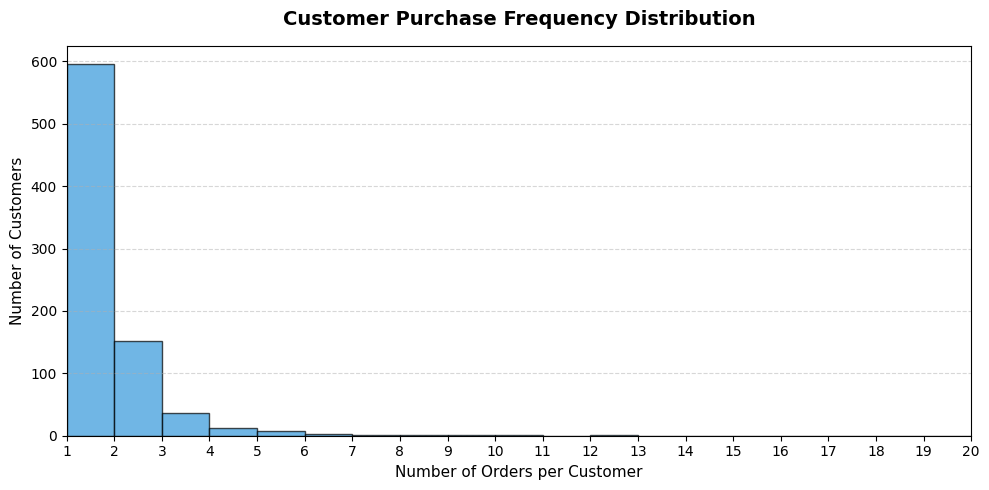

In [14]:
# 1. Filter out missing CustomerIDs and cancelled transactions
dfc1_valid = dfc[(dfc['Quantity'] > 0) & (dfc['CustomerID'].notna())]

# 2. Count unique orders (InvoiceNo) per customer
customer_freq = dfc1_valid.groupby('CustomerID')['InvoiceNo'].nunique()

# 3. Create the Matplotlib Histogram
plt.figure(figsize=(10, 5))

# Plot histogram (bins set up to capture distinct integer order counts)
plt.hist(
    customer_freq,
    bins=range(1, customer_freq.max() + 2),
    color='#3498db',
    edgecolor='black',
    alpha=0.7,
)

# Set x-axis limit to focus on the majority of customers (e.g., up to 20 orders)
plt.xlim(1, 20)
plt.xticks(range(1, 21))

# Labels and Formatting
plt.title(
    'Customer Purchase Frequency Distribution',
    fontsize=14,
    pad=15,
    weight='bold',
)
plt.xlabel('Number of Orders per Customer', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

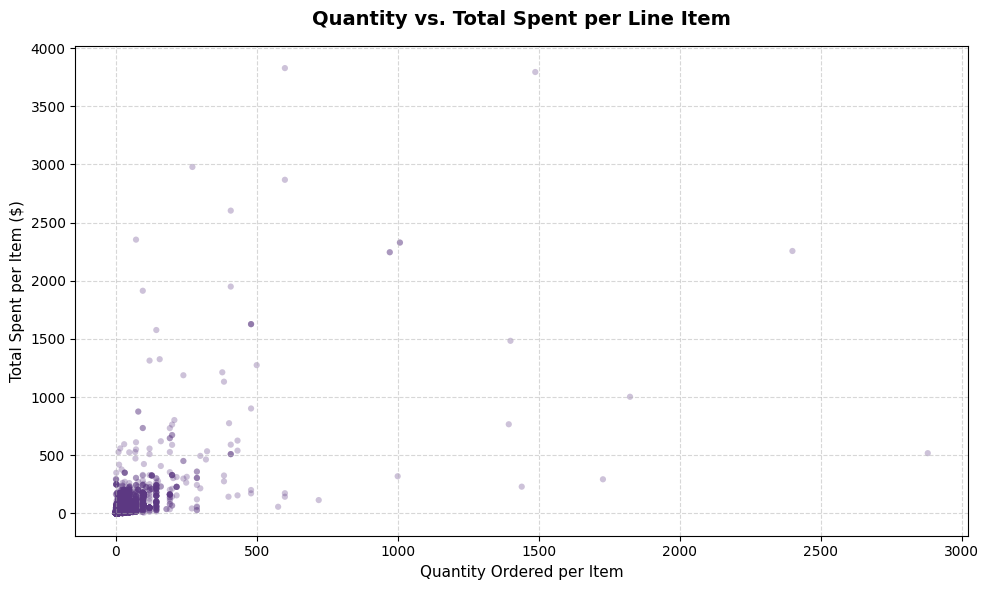

In [15]:
# Next plot is a scatterplot of Quantity vs revenue:

# 1. Calculate Total Spent (Revenue per line item)
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']

# 2. Filter out returns and bad data for cleaner visualization
df_clean = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)]

# 3. Create the Scatter Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean['Quantity'],
    df_clean['TotalSpent'],
    alpha=0.3,  # Transparency helps show point density where thousands overlap
    color='#5c3882',
    edgecolors='none',
    s=20,  # Smaller marker size for crowded datasets
)

# Formatting
plt.title(
    'Quantity vs. Total Spent per Line Item',
    fontsize=14,
    pad=15,
    weight='bold',
)
plt.xlabel('Quantity Ordered per Item', fontsize=11)
plt.ylabel('Total Spent per Item ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

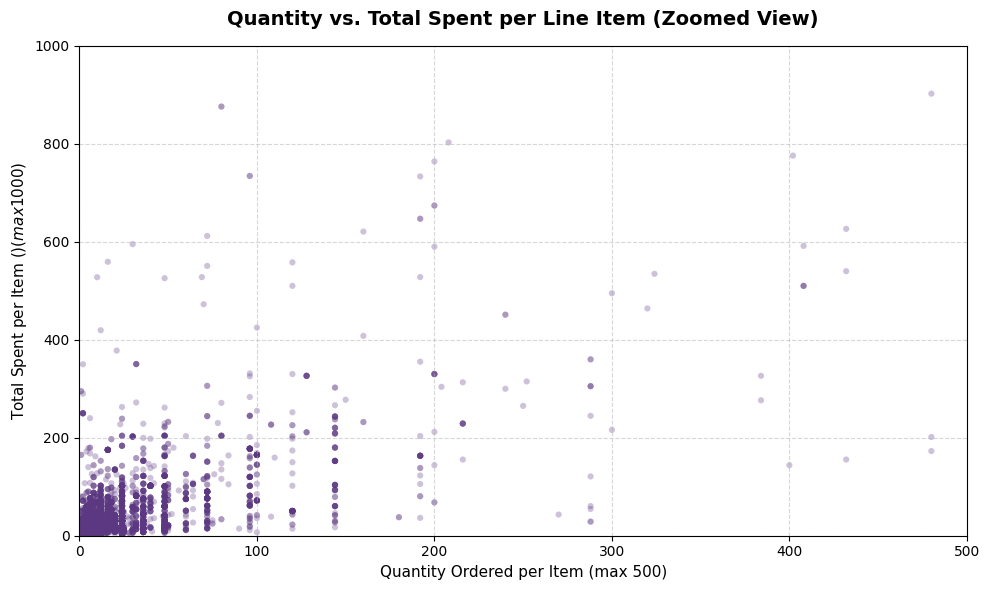

In [16]:
# As it can be seen from the scatterplot, majority of data is focused on bottom left corner. We have so many outliers too.
# For a better and more accurate conclusion, let's limit order quantity to 500 and revenue to 1000$.

# 1. Calculate Total Spent
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']

# 2. Filter out returns / non-positive data
df_clean = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)]

# 3. Create Scatter Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean['Quantity'],
    df_clean['TotalSpent'],
    alpha=0.3,
    color='#5c3882',
    edgecolors='none',
    s=20,
)

# --- ZOOM AXES ---
plt.xlim(0, 500)
plt.ylim(0, 1000)

# Formatting
plt.title(
    'Quantity vs. Total Spent per Line Item (Zoomed View)',
    fontsize=14,
    pad=15,
    weight='bold',
)
plt.xlabel('Quantity Ordered per Item (max 500)', fontsize=11)
plt.ylabel('Total Spent per Item ($) (max $1000)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

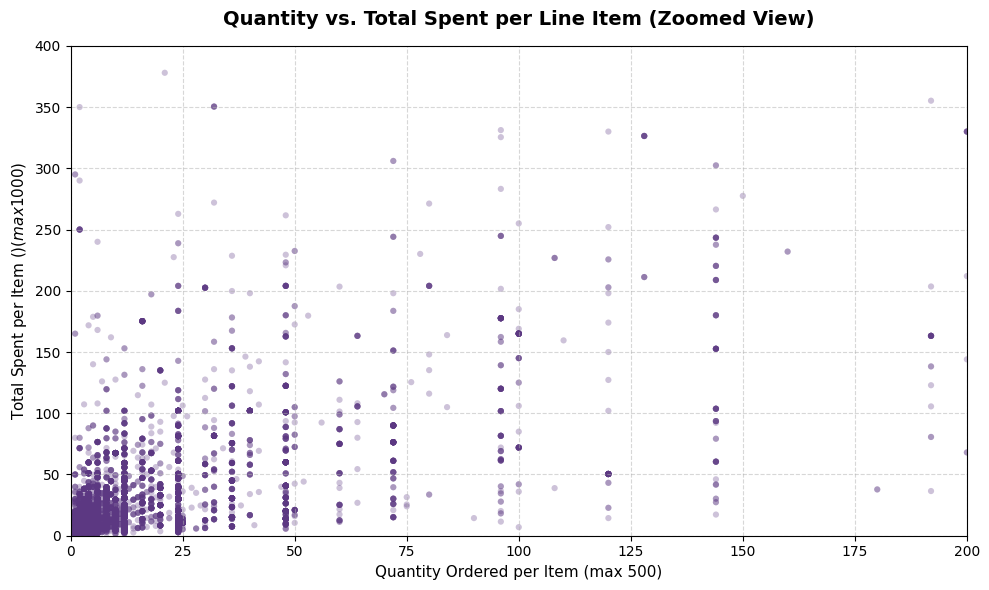

In [18]:
# Let's zoom even more to quantity=200 and revenue 400

# 1. Calculate Total Spent
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']

# 2. Filter out returns / non-positive data
df_clean = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)]

# 3. Create Scatter Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean['Quantity'],
    df_clean['TotalSpent'],
    alpha=0.3,
    color='#5c3882',
    edgecolors='none',
    s=20,
)

# --- ZOOM AXES ---
plt.xlim(0, 200)
plt.ylim(0, 400)

# Formatting
plt.title(
    'Quantity vs. Total Spent per Line Item (Zoomed View)',
    fontsize=14,
    pad=15,
    weight='bold',
)
plt.xlabel('Quantity Ordered per Item (max 500)', fontsize=11)
plt.ylabel('Total Spent per Item ($) (max $1000)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Dataset start date: 2010-12-01 08:26:00
Dataset end date:   2010-12-16 19:22:00
Total date span:    15 days


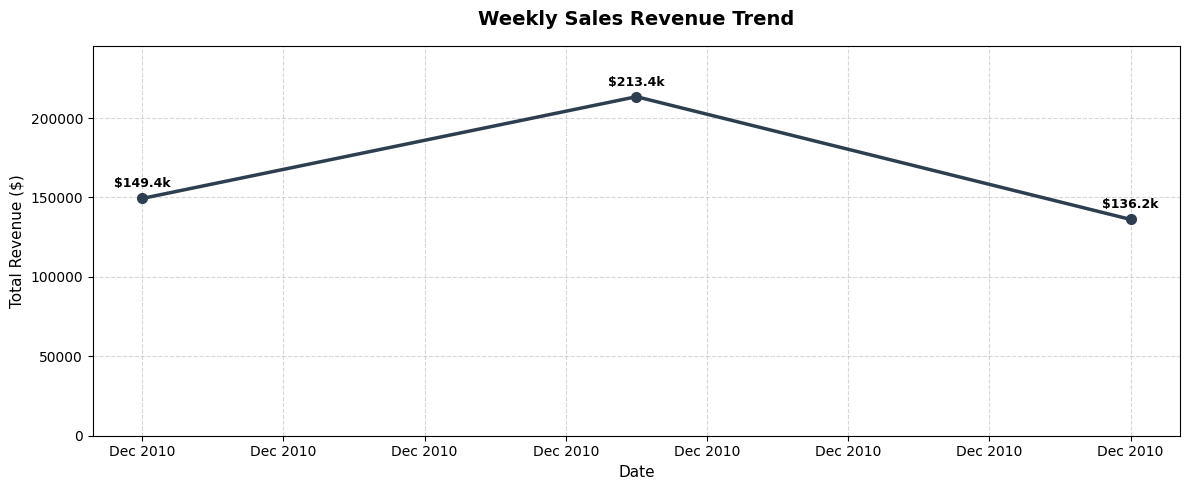

In [22]:
# 1. Force robust datetime conversion (handles strings, timestamps, etc.)
dfc['InvoiceDate'] = pd.to_datetime(dfc['InvoiceDate'], errors='coerce')

# Drop rows with invalid dates or missing values
df = dfc.dropna(subset=['InvoiceDate'])

# 2. Calculate Total Revenue per row
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']

# Filter valid transactions
df_clean = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)].copy()

# 3. Inspect date range span
min_date = df_clean['InvoiceDate'].min()
max_date = df_clean['InvoiceDate'].max()
day_span = (max_date - min_date).days

print(f'Dataset start date: {min_date}')
print(f'Dataset end date:   {max_date}')
print(f'Total date span:    {day_span} days')

# 4. Set index and resample
df_indexed = df_clean.set_index('InvoiceDate')

# Determine frequency based on span length
if day_span <= 60:
    # If dataset spans <= 2 months, resample by WEEK ('W') or DAY ('D') to avoid single-point plot
    sales_trend = df_indexed['TotalSpent'].resample('W').sum()
    freq_label = 'Weekly'
else:
    # Resample by Month ('MS' = Month Start is cleaner for alignment)
    sales_trend = df_indexed['TotalSpent'].resample('MS').sum()
    freq_label = 'Monthly'

# Drop trailing empty periods (if any)
sales_trend = sales_trend[sales_trend > 0]

# 5. Create Plot with Matplotlib
plt.figure(figsize=(12, 5))

plt.plot(
    sales_trend.index,
    sales_trend.values,
    marker='o',
    linewidth=2.5,
    markersize=7,
    color='#2c3e50',
)

# Format X-axis ticks nicely
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

# Annotate each point with formatted value
for x_val, y_val in sales_trend.items():
    plt.annotate(
        f'${y_val/1000:,.1f}k',
        (x_val, y_val),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        weight='bold',
    )

plt.title(
    f'{freq_label} Sales Revenue Trend', fontsize=14, weight='bold', pad=15
)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust y-limits slightly so annotations aren't cut off at the top
plt.ylim(0, sales_trend.max() * 1.15)

plt.tight_layout()
plt.show()

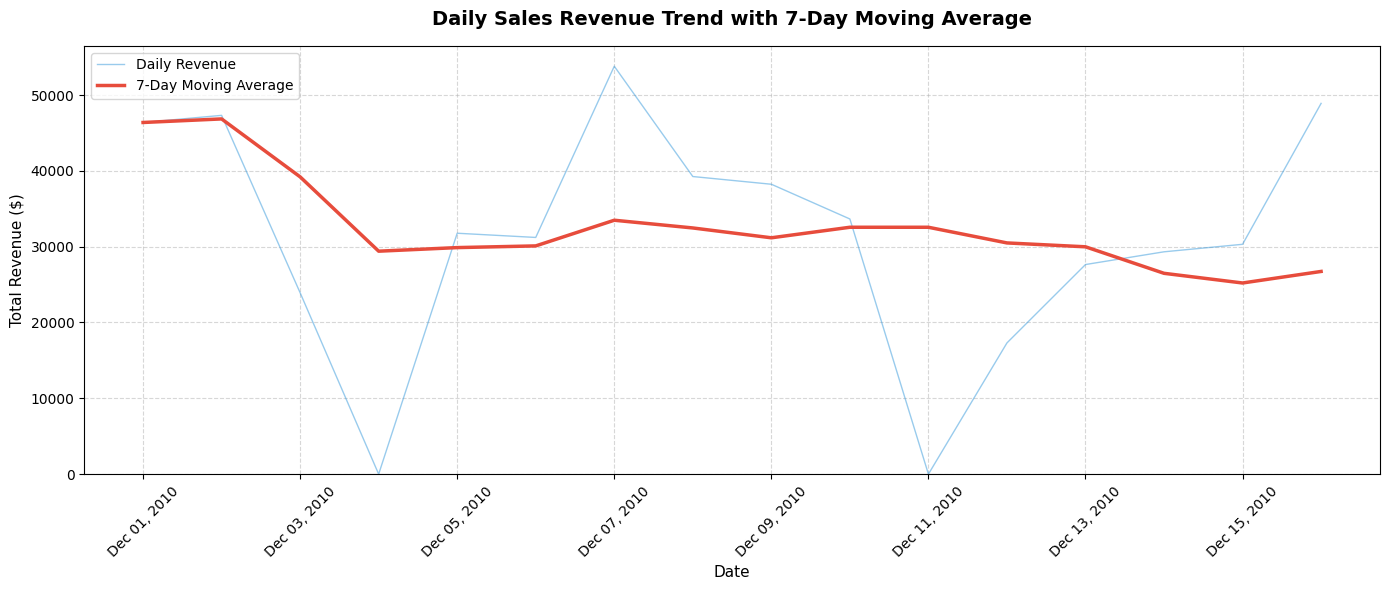

In [23]:
# 1. Ensure clean datetimes and calculate revenue
dfc['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
dfc = dfc.dropna(subset=['InvoiceDate'])
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']

# 2. Filter valid sales transactions
df_clean = dfc[(dfc['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

# 3. Aggregate by Day ('D')
df_indexed = df_clean.set_index('InvoiceDate')
daily_sales = df_indexed['TotalSpent'].resample('D').sum()

# 4. Calculate a 7-day rolling average to highlight the smooth trend
daily_sales_7d_ma = daily_sales.rolling(window=7, min_periods=1).mean()

# 5. Create Plot with Matplotlib
plt.figure(figsize=(14, 6))

# Plot daily raw data
plt.plot(
    daily_sales.index,
    daily_sales.values,
    color='#3498db',
    linewidth=1,
    alpha=0.5,
    label='Daily Revenue',
)

# Plot 7-day moving average on top
plt.plot(
    daily_sales_7d_ma.index,
    daily_sales_7d_ma.values,
    color='#e74c3c',
    linewidth=2.5,
    label='7-Day Moving Average',
)

# Format X-axis to display clean date ticks automatically
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %Y'))
ax.xaxis.set_major_locator(
    mdates.AutoDateLocator()
)  # Automatically picks readable intervals
plt.xticks(rotation=45)

# Labels & Formatting
plt.title(
    'Daily Sales Revenue Trend with 7-Day Moving Average',
    fontsize=14,
    weight='bold',
    pad=15,
)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', frameon=True)

# Ensure y-axis starts at zero
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

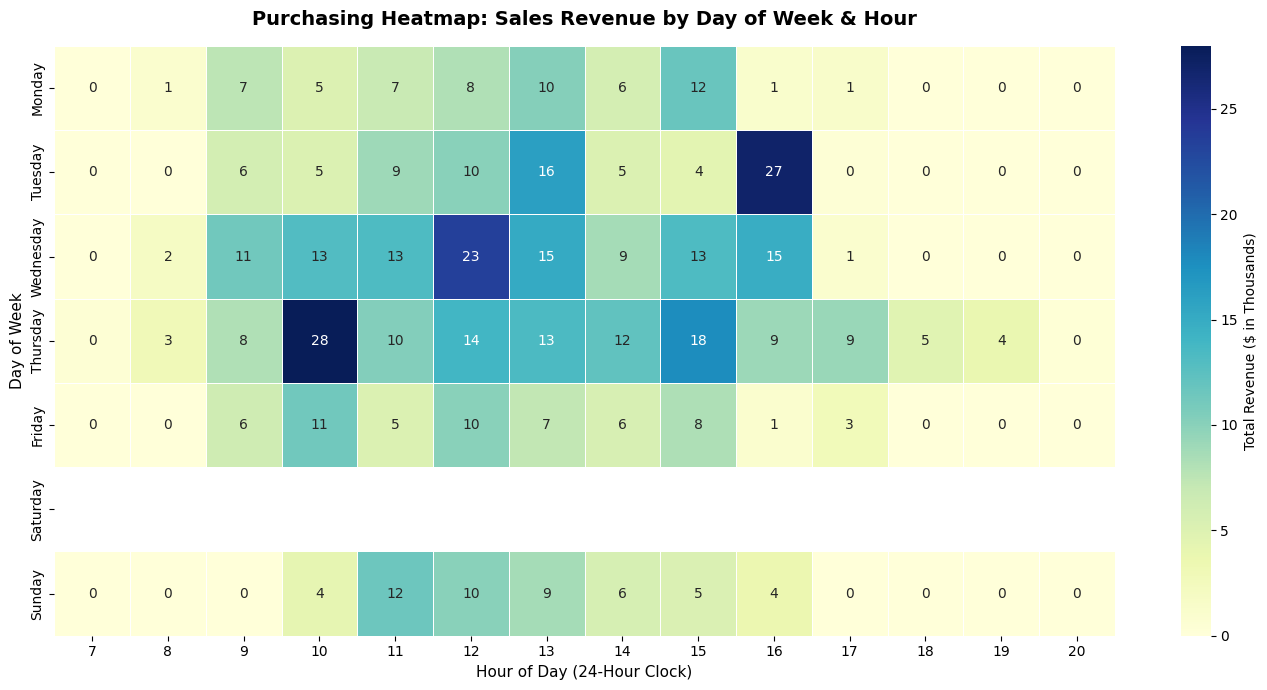

In [25]:
# Now, let's make some heatmaps:

# 1. Ensure InvoiceDate is datetime and filter valid sales
dfc['InvoiceDate'] = pd.to_datetime(
    dfc['InvoiceDate'], format='mixed', errors='coerce'
)
df_clean = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)].copy()

# 2. Extract Hour and Day of Week from InvoiceDate
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

# 3. Create Total Spent (Revenue) per transaction
df_clean['TotalSpent'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 4. Pivot data into a Day x Hour grid (calculating total revenue or order count)
# Grouping by TotalSpent sum (you can change 'sum' to 'count' for transaction volume)
heatmap_data = df_clean.pivot_table(
    index='DayOfWeek', columns='Hour', values='TotalSpent', aggfunc='sum'
).fillna(0)

# Reorder days logically (Monday to Sunday)
days_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]
heatmap_data = heatmap_data.reindex(days_order)

# 5. Plot the Heatmap
plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data / 1000,  # Convert values to Thousands ($k) for cleaner labels
    cmap='YlGnBu',  # Yellow to Green-Blue gradient (darker = higher sales)
    annot=True,  # Display dollar values inside cells
    fmt='.0f',  # Round numbers to nearest whole $k
    cbar_kws={'label': 'Total Revenue ($ in Thousands)'},
    linewidths=0.5,
    linecolor='white',
)

# Formatting
plt.title(
    'Purchasing Heatmap: Sales Revenue by Day of Week & Hour',
    fontsize=14,
    weight='bold',
    pad=15,
)
plt.xlabel('Hour of Day (24-Hour Clock)', fontsize=11)
plt.ylabel('Day of Week', fontsize=11)

plt.tight_layout()
plt.show()

In [26]:
# From the heatmap above, we can see high sales moments of a week.
# Best time of sales is Thursday at 10am, then Tuesday at 4pm, and then Wednesday at 12noon.

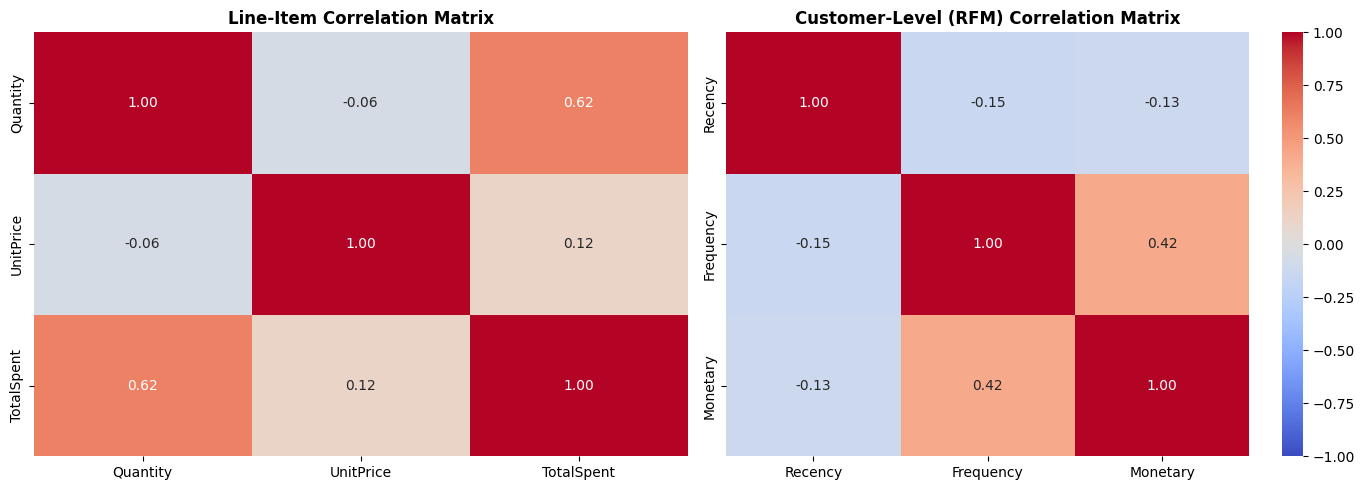

In [27]:
# Now I want to investigate correlations. I think it is most meaningful to investigate correlation for UnitPrice vs Quantity, and Revenue vs Quantity.

# 1. Feature Engineering
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']
df_clean = df[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)].copy()

# --- MATRIX 1: Line-Item Level Correlations ---
line_item_corr = df_clean[['Quantity', 'UnitPrice', 'TotalSpent']].corr()

# --- MATRIX 2: Customer Aggregated Correlations (RFM Level) ---
# Calculate Recency reference date (max date + 1 day)
max_date = df_clean['InvoiceDate'].max()

customer_df = (
    df_clean.groupby('CustomerID')
    .agg(
        Recency=('InvoiceDate', lambda x: (max_date - x.max()).days),
        Frequency=('InvoiceNo', 'nunique'),
        Monetary=('TotalSpent', 'sum'),
    )
    .reset_index()
)

customer_corr = customer_df[['Recency', 'Frequency', 'Monetary']].corr()

# --- Plotting Side-by-Side Correlation Heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Line Item Correlations
sns.heatmap(
    line_item_corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=axes[0],
    cbar=False,
)
axes[0].set_title('Line-Item Correlation Matrix', fontsize=12, weight='bold')

# Plot 2: Customer-Level RFM Correlations
sns.heatmap(
    customer_corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=axes[1],
)
axes[1].set_title(
    'Customer-Level (RFM) Correlation Matrix', fontsize=12, weight='bold'
)

plt.tight_layout()
plt.show()

In [28]:
# As it can be seen from the above heatmap, the only meaningful correlation is between Quantity and Total-Spent which is +0.62.

In [29]:
# Now it is time to make a hypothesis.

# Context: We observed that some customers make frequent repeat orders while others purchase only once.
# Does higher purchase frequency actually lead to higher overall lifetime revenue, or do repeat buyers just place smaller, split orders?

# Null Hypothesis ($H_0$): There is no correlation between a customer's purchase frequency (number of unique invoices) and their total monetary spend (r = 0).
# Alternative Hypothesis ($H_A$): There is a positive correlation between purchase frequency and total monetary spend (r > 0).


In [30]:
# step 1: Formal Hypothesis StatementNull Hypothesis (H0): There is no correlation between purchase frequency and total monetary spend.
# Alternative Hypothesis (HA): There is a positive correlation between purchase frequency and total monetary spend.
# Significance Level alpha = 0.05 (95% confidence level).

           STATISTICAL HYPOTHESIS TEST RESULTS    
Sample Size (Unique Customers): 813
Pearson Correlation (r):       0.4185  (p-value: 8.1688e-36)
Spearman Rank Correlation (r):  0.4876  (p-value: 8.8053e-50)
--------------------------------------------------
VERDICT: REJECT THE NULL HYPOTHESIS (H0).
Conclusion: Statistically significant positive correlation exists between Frequency and Monetary spend.


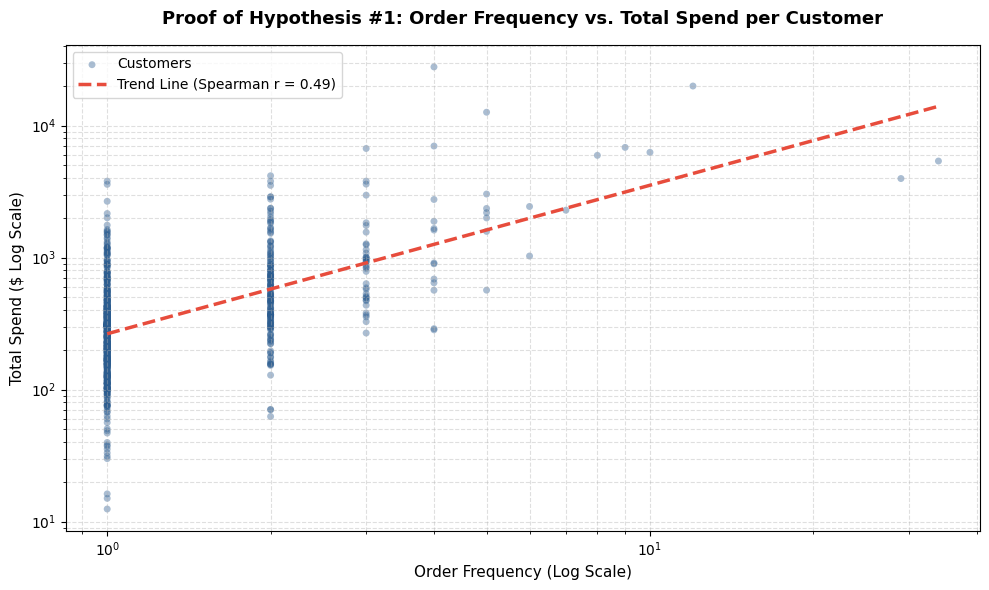

In [32]:
# 1. Clean data & create TotalSpent column
dfc['InvoiceDate'] = pd.to_datetime(
    dfc['InvoiceDate'], format='mixed', errors='coerce'
)
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']

# Filter valid transactions and drop missing CustomerIDs
df_clean = dfc[
    (df['Quantity'] > 0) & (df['UnitPrice'] > 0) & (df['CustomerID'].notna())
].copy()

# 2. Aggregate metrics per customer
customer_rfm = (
    df_clean.groupby('CustomerID')
    .agg(
        Frequency=('InvoiceNo', 'nunique'),
        Monetary=('TotalSpent', 'sum'),
    )
    .reset_index()
)

# 3. Calculate Correlation Coefficients and P-Values
pearson_r, pearson_p = stats.pearsonr(
    customer_rfm['Frequency'], customer_rfm['Monetary']
)
spearman_r, spearman_p = stats.spearmanr(
    customer_rfm['Frequency'], customer_rfm['Monetary']
)

# 4. Print Formal Statistical Output
print('==================================================')
print('           STATISTICAL HYPOTHESIS TEST RESULTS    ')
print('==================================================')
print(f'Sample Size (Unique Customers): {len(customer_rfm):,}')
print(
    f'Pearson Correlation (r):       {pearson_r:.4f}  (p-value: {pearson_p:.4e})'
)
print(
    f'Spearman Rank Correlation (r):  {spearman_r:.4f}  (p-value: {spearman_p:.4e})'
)
print('--------------------------------------------------')

alpha = 0.05
if spearman_p < alpha:
    print('VERDICT: REJECT THE NULL HYPOTHESIS (H0).')
    print(
        'Conclusion: Statistically significant positive correlation exists between Frequency and Monetary spend.'
    )
else:
    print('VERDICT: FAIL TO REJECT THE NULL HYPOTHESIS (H0).')
print('==================================================')

# 5. Plot Log-Log Scatter Plot with Trend Line (to handle skewness visually)
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_rfm['Frequency'],
    customer_rfm['Monetary'],
    alpha=0.4,
    color='#2b5c8f',
    edgecolors='none',
    s=25,
    label='Customers',
)

# Log-scale transformation for display clarity
plt.xscale('log')
plt.yscale('log')

# Calculate linear regression line on log values for visualization
log_freq = np.log10(customer_rfm['Frequency'])
log_monetary = np.log10(customer_rfm['Monetary'])
slope, intercept = np.polyfit(log_freq, log_monetary, 1)

x_vals = np.linspace(log_freq.min(), log_freq.max(), 100)
plt.plot(
    10**x_vals,
    10 ** (slope * x_vals + intercept),
    color='#e74c3c',
    linewidth=2.5,
    linestyle='--',
    label=f'Trend Line (Spearman r = {spearman_r:.2f})',
)

plt.title(
    'Proof of Hypothesis #1: Order Frequency vs. Total Spend per Customer',
    fontsize=13,
    weight='bold',
    pad=15,
)
plt.xlabel('Order Frequency (Log Scale)', fontsize=11)
plt.ylabel('Total Spend ($ Log Scale)', fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

In [33]:
# End of Exploratory Data Analysis section.
# In the next section, we will work on 'Feauture Engineering'.